# house rent 데이터셋 분석 및 모델링 해보기
house rent 데이터셋은 주택별 특징 데이터들을 가지고 있으며 해당 데이터를 이요해서 가격을 책정하는 데이터 셋으로 유명한 데이터 셋입니다. 이번에는 비교적간단한 모델들을 이용하여 데이터를 분석해보고 예측기를 만들어보는 과정을 가져보도록 하겠습니다.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("C:\\LANG_CHAIN_2026\\2026-05-19_KDT_lang_chain\\workspace\\python\\099_data\\House_Rent_Dataset.csv")

rent_df = pd.read_csv(DATA_PATH)

display(rent_df.head())
print("데이터 크기:", rent_df.shape)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


데이터 크기: (4746, 12)


In [2]:
rent_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [3]:
display(rent_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
BHK,4746.0,2.083860,0.832256,1.0,2.0,2.0,3.0,6.0
Rent,4746.0,34993.451327,78106.412937,1200.0,10000.0,16000.0,33000.0,3500000.0
Size,4746.0,967.490729,634.202328,10.0,550.0,850.0,1200.0,8000.0
Bathroom,4746.0,1.965866,0.884532,1.0,1.0,2.0,2.0,10.0


In [4]:
summary = pd.DataFrame({
    "dtype": rent_df.dtypes,
    "missing_count": rent_df.isna().sum(),
    "missing_rate": rent_df.isna().mean(),
    "unique_count": rent_df.nunique()
})

display(summary)
print("중복 행 개수:", rent_df.duplicated().sum())

,dtype,missing_count,missing_rate,unique_count
Posted On,str,0,0.0,81
BHK,int64,0,0.0,6
Rent,int64,0,0.0,243
Size,int64,0,0.0,615
Floor,str,0,0.0,480
Area Type,str,0,0.0,3
Area Locality,str,0,0.0,2235
City,str,0,0.0,6
Furnishing Status,str,0,0.0,3
Tenant Preferred,str,0,0.0,3


중복 행 개수: 0


In [6]:
rent_df["BHK"].unique()

array([2, 1, 3, 6, 4, 5])

일단 위와 같이 작업을 해보았습니다. 데이터는 각각 약 4700개 정도 있으며 결측치는 존재하지 않는 다는 것입니다.

타입의 경우에는 정수형이 4개로 크기, 화장실 등에 대한 개수/크기와 Rent라는 결과 가격이 존재하게 됩니다.

저희는 Rent를 찾기 위해 작업을 하게 될 것 같으며 다른 문자열 컬럼에서 확인해야할 부분은 Floor (몇층 건물의 몇층인지로 추정)과 어떤 도시에 있는지에 대해서 설명해주는 컬럼이 거의 고유한 값이 존재하지 않아 원 핫 인코딩을 할 수 없다는 점입니다.

숫자형 타입에서 값들은 조금의 이상치가 있을 것으로 추정되는 (백분위수와 max의 차이가 큰 부분)부분이 보이긴 하지만 그중 더 신경써야할 부분은 Rent로 상위 가격들에 의해 평균이 4분위수의 3분위 지점을 넘어가는 것을 확인할 수 있습니다.

다음으로는 아마 고윳값이 많은 범주형을 범위로 나누어 작업을 하거나 숫자를 정규화, 결측치는 없으니 넘어가며 각 컬럼별 정확한 사용법을 알아보아야할 것 같습니다.

In [17]:
rent_df["Floor"].unique()[:10]

<StringArray>
['Ground out of 2',      '1 out of 3',      '1 out of 2', 'Ground out of 1',
 'Ground out of 4',      '1 out of 4',      '1 out of 1', 'Ground out of 3',
      '2 out of 3',      '4 out of 5']
Length: 10, dtype: str

Floor의 경우에는 범주형으로 보통 `${현재층} out of ${총 층}`의 형태로 구성되어있습니다.

이를 구조분해하면 보통 Ground를 1로 치환함과 동시에 2개의 컬럼 `[실제 층, 총 층 수]`로 나누기 좋은 구조가 됩니다.



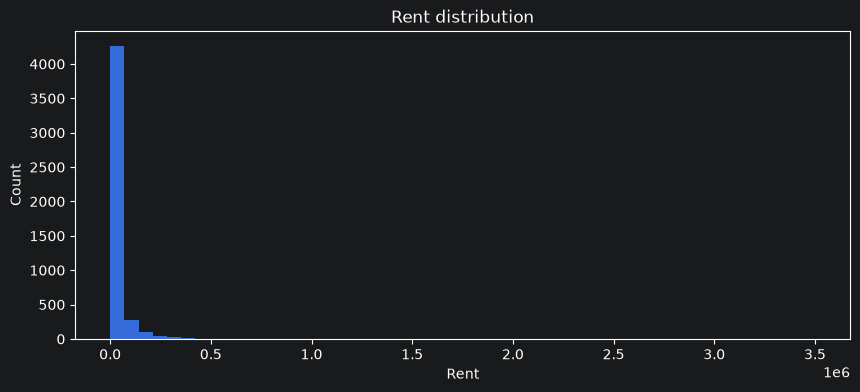

In [18]:
import numpy as np

plt.figure(figsize=(10, 4))
# 가격별 범위를 히스토그램으로 나타내기
plt.hist(rent_df["Rent"], bins=50)
plt.title("Rent distribution")
plt.xlabel("Rent")
plt.ylabel("Count")
plt.show()

위의 히스토그램을 보면 Rent의 최솟값부터 최댓값까지를 50등분하여 히스토그램으로 나타내었을 때 하위 1분위가 거의 4000 초반대의 개수가 나오는 것을 확인할 수 있엇습니다.

C:\Users\hurwa\AppData\Local\Temp\ipykernel_16680\3246185322.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(rent_df["Rent"], vert=False)


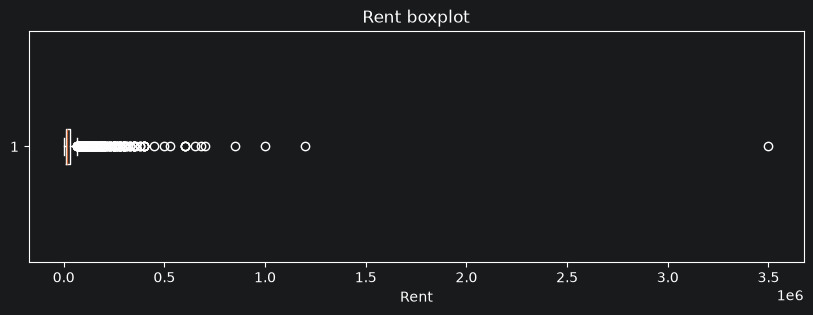

In [19]:
plt.figure(figsize=(10, 3))
plt.boxplot(rent_df["Rent"], vert=False)
plt.title("Rent boxplot")
plt.xlabel("Rent")
plt.show()

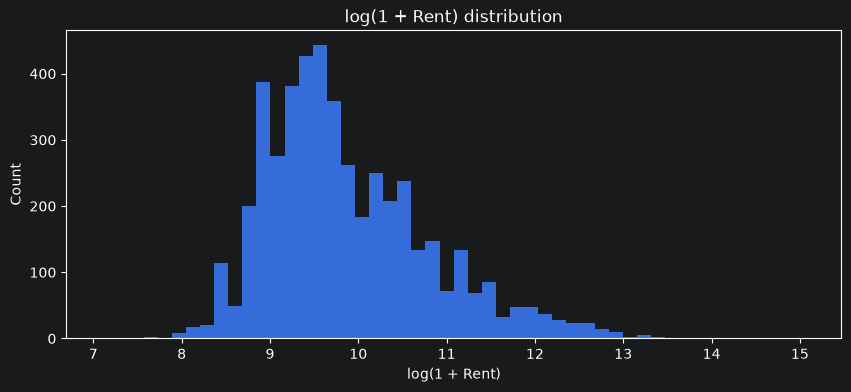

In [20]:
log_rent = np.log1p(rent_df["Rent"])

plt.figure(figsize=(10, 4))
plt.hist(log_rent, bins=50)
plt.title("log(1 + Rent) distribution")
plt.xlabel("log(1 + Rent)")
plt.ylabel("Count")
plt.show()

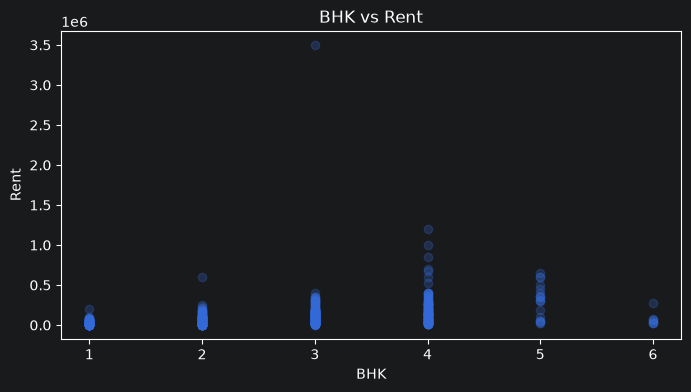

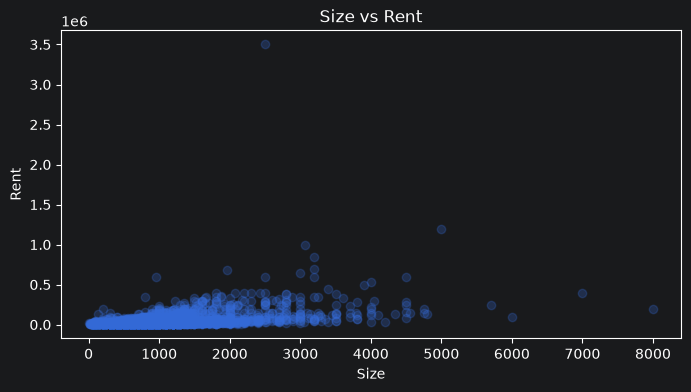

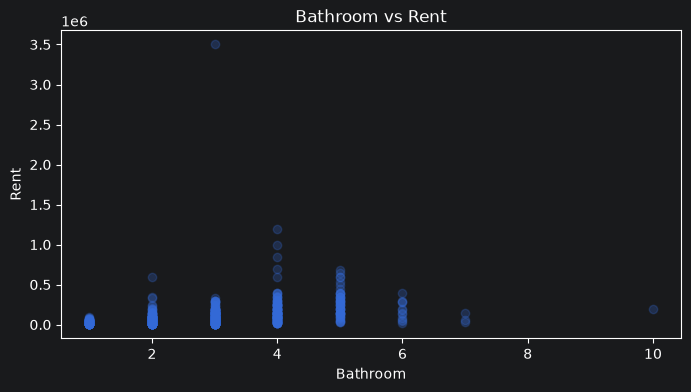

In [24]:
numeric_features = ["BHK", "Size", "Bathroom"]

for feature in numeric_features:
    plt.figure(figsize=(8, 4))

    plt.scatter(
        rent_df[feature],
        rent_df["Rent"],
        alpha=0.25
    )

    plt.title(f"{feature} vs Rent")
    plt.xlabel(feature)
    plt.ylabel("Rent")
    plt.show()

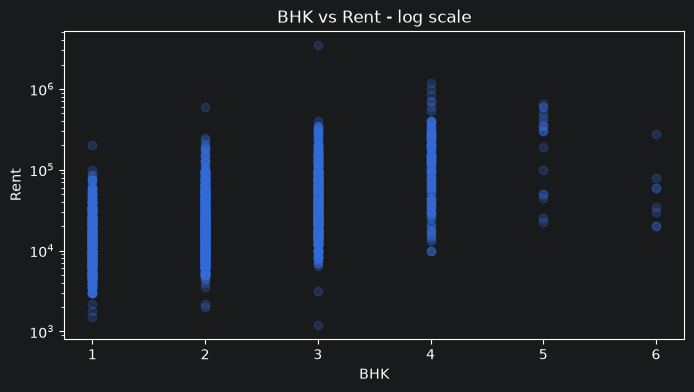

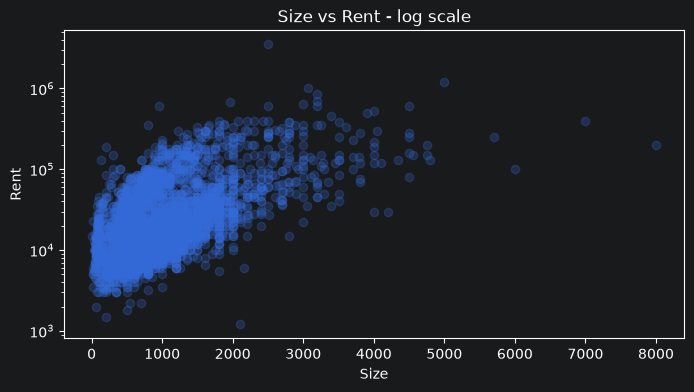

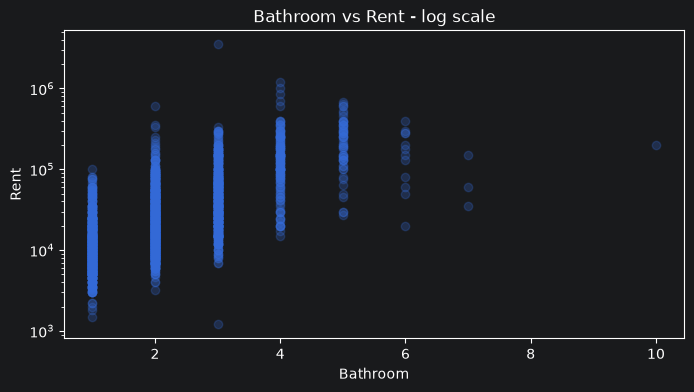

In [25]:

for feature in numeric_features:
    plt.figure(figsize=(8, 4))

    plt.scatter(
        rent_df[feature],
        rent_df["Rent"],
        alpha=0.25
    )

    # 축을 log로 지정해서 같은 배율이 같은 범위로 지정
    # 예를 들어서 10 -> 100 범위와 100 -> 1000 범위가 동일하게 지정됨
    plt.yscale("log")

    plt.title(f"{feature} vs Rent - log scale")
    plt.xlabel(feature)
    plt.ylabel("Rent")
    plt.show()

In [27]:
city_summary = (
    rent_df.groupby("City")["Rent"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=False)
)

display(city_summary)

,count,mean,median,min,max
City,,,,,
Mumbai,972,85321.204733,52000.0,4500,1200000
Delhi,605,29461.983471,17000.0,2000,530000
Chennai,891,21614.092031,14000.0,3000,600000
Bangalore,886,24966.365688,14000.0,3500,3500000
Hyderabad,868,20555.048387,14000.0,1200,400000
Kolkata,524,11645.173664,8500.0,1500,180000


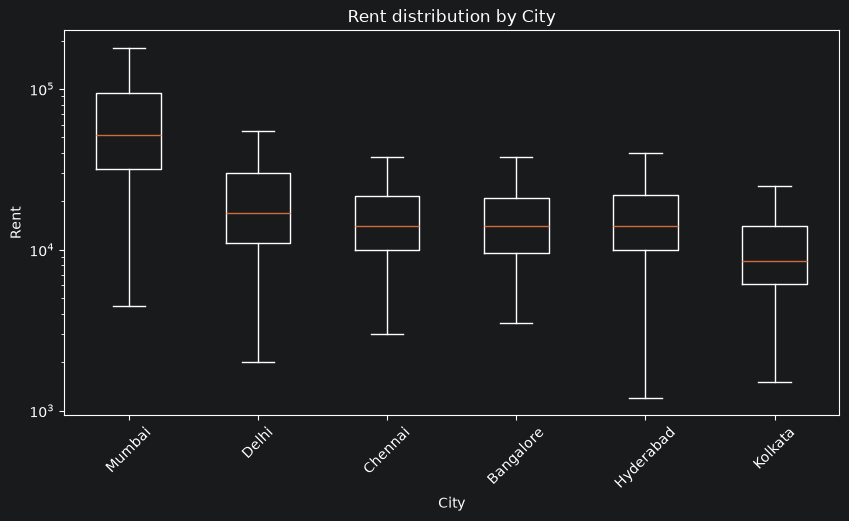

In [28]:
cities = city_summary.index.tolist()

city_rents = [
    rent_df.loc[rent_df["City"] == city, "Rent"]
    for city in cities
]

plt.figure(figsize=(10, 5))
plt.boxplot(city_rents, tick_labels=cities, showfliers=False)

plt.yscale("log")
plt.title("Rent distribution by City")
plt.xlabel("City")
plt.ylabel("Rent")
plt.xticks(rotation=45)
plt.show()

## 잠깐 라이브러리 개념
`matplotlib`에서는 `pyplot` 모듈을 제공합니다. `plt`는 그리는 공간인 `figure` 또는 안에 넣는 `ax`, 여러 도표를 그릴 수 있는 메서드를 제공합니다. (정확히는 하나만 그릴 때에는 plt를 그대로 사용하며 그래프를 세밀하게 제어할 때에는 `subplots`를 통해 ax, fig를 사용하게 됩니다.)

보통 순서는
1. figure의 figsize 설정
2. 도표 선택과 함께 내부 데이터 설정
3. x축과 y축의 눈금, 범위, 보여주는 방식 설정
4. 라벨링 작업
5. show를 통한 출력
으로 이루어지게 됩니다.

df에서는 groupby를 통해 여러 행들을 특정 컬럼들의 집합 으로 나눌 수 있으며 `.agg` 함수 내부에 사용할 함수를 문자열과 리스트로 넣으면 여러 집계 컬럼과 행에는 그룹으로 이루어진 테이블을 출력할 수 있습니다.

박스 플롯의 경우에는 박스 위와 아래 범위는 각각 Q3, Q1 이라고 표현하며 박스 안에 있는 하나의 가로선은 중앙값으로 Q2라고 표현하게 됩니다. 가장 바깥쪽에 있는 두 표현의 경우에는 whisker이라고 부르며 각각 IQR 이상치 양 끝을 나타냅니다. (Q1 - 1.5*IQR, Q3 + 1.5*IQR)

중간에 나온 y라벨에 존재하는 `plt.yscale("log")`는 가로축의 범위를 `log`를 기준으로 잡아주는 것입니다. 10^x 를 기준으로 나누게 되어 각각의 같은 간격이더라도 다른 범위를 나타내게 됩니다. 이는 실제 데이터를 바꾸는 것이 아닌 정렬의 상태만 바꾸는 것이 모두입니다.